In [16]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

from backbone import compute_backbone
from backbone.plotting import plot_network

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
df = pd.read_csv("normalized_mi_df.csv", index_col=0)
df = df.fillna(0)

M = df.values
M = (M+M.T)/2
np.fill_diagonal(M, 0.)

node_labels = df.columns.values.tolist()


Optimal alpha  : 0.028290
Modularity Q   : 0.8914
Non-Orphan Ratio       : 0.9873
Combined score : 0.8801
# communities  : 16
Backbone nodes : 79
Backbone edges : 141


/home/fciulla/coding/miscellanea/networksML/jul2026/backbone/__init__.py:173: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


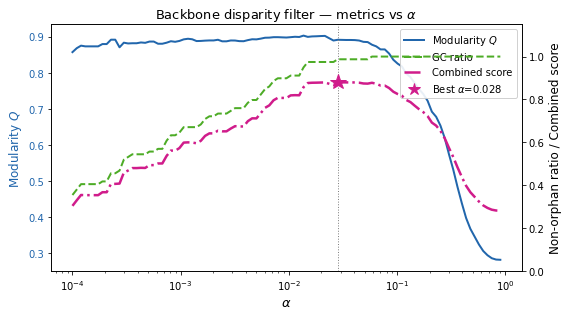

In [17]:
result = compute_backbone(
    M,
    #alpha=None,         # automatic golden-section search
    alpha = np.logspace(-4, np.log10(0.9), 101),
    method="louvain",
    tol=1e-3,
    plot=True,
    save_plot="backbone_metrics.png",
    
)

# ── Results ───────────────────────────────────────────────────────────────────
print(f"\nOptimal alpha  : {result.alpha:.6f}")
print(f"Modularity Q   : {result.score:.4f}")
print(f"Non-Orphan Ratio       : {result.non_orphan_ratio:.4f}")
print(f"Combined score : {result.combined_score:.4f}")
print(f"# communities  : {len(set(result.communities.values()))}")
print(f"Backbone nodes : {result.backbone.number_of_nodes()}")
print(f"Backbone edges : {result.backbone.number_of_edges()}")


/tmp/ipykernel_458812/842464844.py:9: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


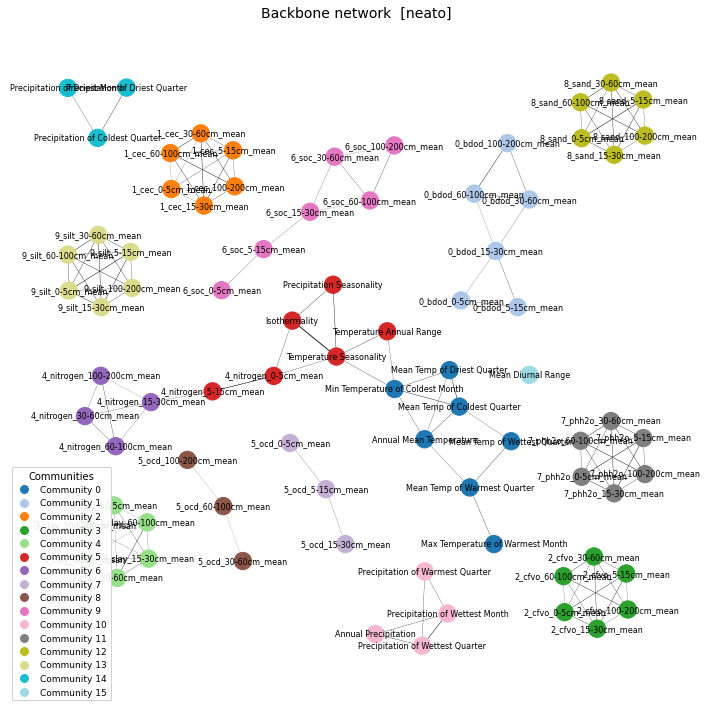

In [24]:
fig = plot_network(
    result.backbone,
    communities=result.communities,
    labels=node_labels,
    title="Backbone network",
    save_path="backbone_network.png",
    layout='neato'
)
fig.show()